# Notebook 11 — LOSO-Feature-Selection (NB06 ⊕ NB09)

**Idee:** NB09 hat gezeigt, dass *neue* Dynamik-Features die Generalisierung verbessern
(LOSO 76 % → 79.7 %). Gleichzeitig deutete der **DYN-Fund** darauf hin, dass manche
*alten* Features **session-spezifisches Rauschen** sind — z.B. `pitch_mean`, `lin_x_mean`
(= absolute Handyposition). Die pushen das LOO hoch, schaden aber dem LOSO.

**Dieses Notebook kombiniert beides:**
1. Starte mit **PLUS** (52 Features: 36 Base + 16 neu).
2. **Ranke** alle Features nach ihrem Beitrag zur *Cross-Session*-Generalisierung
   (group-aware Permutation Importance).
3. **Wähle** die Teilmenge die das **LOSO** maximiert (Accuracy-Kurve wie NB06,
   aber mit LOSO statt LOO).

**Ziel:** LOSO über die 79.7 % aus NB09 drücken, indem die schädlichen
session-spezifischen Features entfernt werden.

> Auswertung: **Stufe 2** (Apfel/Kaugummi/Skyr/Essen), 25-s-Fenster (wie NB09).

---
## 1. Setup

In [8]:
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch, find_peaks
from scipy.stats import kurtosis, skew

from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut, GroupShuffleSplit
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

CLASSES_RAW  = ['Apfel', 'Kaugummi', 'Skyr', 'Still', 'Essen']
CLASSES_FINE = ['Apfel', 'Kaugummi', 'Skyr', 'Essen']
TO_COARSE    = {'Apfel': 'Essen', 'Kaugummi': 'Essen', 'Skyr': 'Essen',
                'Still': 'Still', 'Essen': 'Essen'}

FS            = 50.0
TRIM_SECS     = 2
WINDOW_SECS   = 25.0    # wie NB09 (79.7 % LOSO-Referenz)
STEP_SECS     = 25.0
MIN_TAIL_SECS = 20.0
K_ME          = 15

def make_pipeline(clf, scale=True):
    return Pipeline([('sc', StandardScaler()), ('clf', clf)]) if scale else clf

SVM = dict(clf=lambda: SVC(kernel='rbf', C=10, class_weight='balanced', random_state=42),
           scale=True, le=False)
MLP = dict(clf=lambda: MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                     solver='adam', max_iter=500, learning_rate_init=0.001,
                                     random_state=42), scale=True, le=True)
print('Setup OK')

Setup OK


---
## 2. Daten + Features (identisch zu NB09)

52 PLUS-Features (36 Base + 16 neu), pro Session gruppiert für LOSO.

In [9]:
DATA_DIR = Path('../data/raw')
_SKIP    = {'Metadata.csv', 'Annotation.csv'}

def preprocess(df):
    df = df.copy(); t = df['seconds_elapsed']
    df = df[(t >= t.iloc[0] + TRIM_SECS) & (t <= t.iloc[-1] - TRIM_SECS)].reset_index(drop=True)
    df['lin_x'] = df['accelerationX']; df['lin_y'] = df['accelerationY']; df['lin_z'] = df['accelerationZ']
    df['magnitude'] = np.sqrt(df['lin_x']**2 + df['lin_y']**2 + df['lin_z']**2)
    return df

def movement_mask(df):
    thr = max(0.02, K_ME * df['magnitude'].median())
    return df['magnitude'].rolling(50, center=True, min_periods=1).max() <= thr

def sliding_windows(df):
    t = df['seconds_elapsed'].values; t_start, t_end = t[0], t[-1]; out = []
    while t_start + MIN_TAIL_SECS <= t_end:
        w = df[(t >= t_start) & (t < t_start + WINDOW_SECS)].reset_index(drop=True)
        if len(w) > 1 and (w['seconds_elapsed'].iloc[-1] - w['seconds_elapsed'].iloc[0]) >= MIN_TAIL_SECS:
            out.append(w)
        t_start += STEP_SECS
    return out

def extract_features_base(df):
    feats = {}
    for col in ['lin_x', 'lin_y', 'lin_z', 'magnitude']:
        feats[f'{col}_mean'] = df[col].mean(); feats[f'{col}_std'] = df[col].std(); feats[f'{col}_max'] = df[col].abs().max()
    feats['stillness_ratio'] = (df['magnitude'] < 0.02).mean()
    feats['movement_events'] = int((df['magnitude'] > df['magnitude'].quantile(0.75)).sum())
    for col in ['rotationRateX', 'rotationRateY', 'rotationRateZ']:
        feats[f'{col}_mean'] = df[col].mean(); feats[f'{col}_std'] = df[col].std(); feats[f'{col}_max'] = df[col].abs().max()
    for col in ['pitch', 'roll', 'yaw']:
        feats[f'{col}_mean'] = df[col].mean(); feats[f'{col}_std'] = df[col].std(); feats[f'{col}_range'] = df[col].max() - df[col].min()
    nperseg = min(256, len(df) // 2)
    freqs, psd = welch(df['magnitude'].values, fs=FS, nperseg=nperseg)
    chew = (freqs >= 0.5) & (freqs <= 4.0); cf, cp = freqs[chew], psd[chew]
    feats['total_power'] = float(psd.sum()); feats['chew_band_power'] = float(cp.sum())
    feats['rhythmicity'] = feats['chew_band_power'] / feats['total_power'] if feats['total_power'] > 0 else 0.0
    feats['dominant_chew_freq'] = float(cf[np.argmax(cp)]) if len(cp) > 0 else 0.0
    return feats

NEW_FEATURES = ['mag_kurtosis', 'mag_skew', 'crest_factor', 'jerk_mean', 'jerk_std',
                'spectral_entropy', 'spectral_centroid', 'spectral_bandwidth',
                'band_power_slow', 'band_power_mid', 'band_power_fast', 'high_freq_power',
                'ac_peak_height', 'chew_freq_ac', 'chews_per_sec', 'inter_chew_cv']

def extract_new_features(df):
    f = {k: 0.0 for k in NEW_FEATURES}
    mag = df['magnitude'].values; t = df['seconds_elapsed'].values
    dur = (t[-1] - t[0]) if len(t) > 1 else 0.0
    rms = np.sqrt(np.mean(mag**2)) if len(mag) else 0.0
    if len(mag) > 3: f['mag_kurtosis'] = float(kurtosis(mag))
    if len(mag) > 2: f['mag_skew'] = float(skew(mag))
    if rms > 1e-9:   f['crest_factor'] = float(np.max(np.abs(mag)) / rms)
    if len(mag) > 2:
        jerk = np.diff(mag) * FS; f['jerk_mean'] = float(np.mean(np.abs(jerk))); f['jerk_std'] = float(np.std(jerk))
    nperseg = min(256, len(mag) // 2)
    if nperseg >= 2:
        freqs, psd = welch(mag, fs=FS, nperseg=nperseg); tot = psd.sum()
        if tot > 0:
            p = psd / tot; pp = p[p > 0]
            f['spectral_entropy'] = float(-np.sum(pp * np.log2(pp)) / np.log2(len(p)))
            f['spectral_centroid'] = float(np.sum(freqs * p))
            f['spectral_bandwidth'] = float(np.sqrt(np.sum((freqs - f['spectral_centroid'])**2 * p)))
            band = lambda lo, hi: float(psd[(freqs >= lo) & (freqs < hi)].sum() / tot)
            f['band_power_slow'] = band(0.5, 1.5); f['band_power_mid'] = band(1.5, 2.5)
            f['band_power_fast'] = band(2.5, 4.0); f['high_freq_power'] = band(4.0, 15.0)
    sig = mag - mag.mean() if len(mag) else mag
    if len(sig) > int(FS):
        ac = np.correlate(sig, sig, mode='full')[len(sig) - 1:]; ac = ac / (ac[0] + 1e-12)
        lo, hi = int(FS / 4.0), min(int(FS / 0.5), len(ac) - 1)
        if hi > lo:
            peak = np.argmax(ac[lo:hi]) + lo; f['ac_peak_height'] = float(ac[peak]); f['chew_freq_ac'] = float(FS / peak)
    if len(mag) > 5 and mag.std() > 0:
        peaks, _ = find_peaks(mag, distance=max(1, int(FS * 0.2)), prominence=mag.std())
        if dur > 0: f['chews_per_sec'] = float(len(peaks) / dur)
        if len(peaks) > 1:
            iv = np.diff(t[peaks])
            if iv.mean() > 0: f['inter_chew_cv'] = float(iv.std() / iv.mean())
    return f

# Sessions laden + Datensatz bauen (nur Essen / Stufe 2)
rows, y_list, grp_list = [], [], []
session_counter = 0
for zf in sorted(DATA_DIR.glob('*.zip')):
    for cls in CLASSES_RAW:
        if zf.name.startswith(cls + '_'):
            with zipfile.ZipFile(zf) as z:
                csv_name = next(fn for fn in z.namelist() if fn.endswith('.csv') and fn not in _SKIP)
                with z.open(csv_name) as fh:
                    dfp = preprocess(pd.read_csv(fh))
            if TO_COARSE[cls] == 'Essen':
                for w in sliding_windows(dfp):
                    clean = w[movement_mask(w)].reset_index(drop=True)
                    if len(clean) > 50:
                        rows.append({**extract_features_base(clean), **extract_new_features(clean)})
                        y_list.append(cls); grp_list.append(session_counter)
            session_counter += 1
            break

X_plus = pd.DataFrame(rows)
FEATURES = list(X_plus.columns)
y_eat = np.array(y_list); grp_eat = np.array(grp_list)
is_new = np.array([fn in NEW_FEATURES for fn in FEATURES])

print(f'Essen-Fenster: {len(X_plus)}  über {len(np.unique(grp_eat))} Sessions')
print(f'Features: {len(FEATURES)}  ({is_new.sum()} neu, {(~is_new).sum()} base)')
for c in CLASSES_FINE:
    print(f'  {c:10s}: {(y_eat==c).sum():3d}')

Essen-Fenster: 320  über 67 Sessions
Features: 52  (16 neu, 36 base)
  Apfel     :  57
  Kaugummi  :  55
  Skyr      : 127
  Essen     :  81


---
## 3. LOSO-Auswertung

In [10]:
def loso_predict(X_np, y_str, groups, cfg):
    le = LabelEncoder().fit(y_str) if cfg.get('le') else None
    y_fit = le.transform(y_str) if le is not None else y_str
    yt, yp = [], []
    for tr, te in LeaveOneGroupOut().split(X_np, y_str, groups):
        if len(np.unique(y_str[tr])) < 2:
            continue
        pipe = make_pipeline(cfg['clf'](), scale=cfg['scale'])
        pipe.fit(X_np[tr], y_fit[tr])
        pred = pipe.predict(X_np[te])
        if le is not None:
            pred = le.inverse_transform(pred)
        yp.extend(np.atleast_1d(pred).tolist()); yt.extend(y_str[te].tolist())
    return np.array(yt), np.array(yp)

def loso_acc(X_np, y_str, groups, cfg):
    yt, yp = loso_predict(X_np, y_str, groups, cfg)
    return accuracy_score(yt, yp)

Xp = X_plus.values
base_loso = loso_acc(Xp[:, ~is_new], y_eat, grp_eat, SVM)
plus_loso = loso_acc(Xp,             y_eat, grp_eat, SVM)
print(f'Referenz LOSO (SVM):  BASE-36 = {base_loso:.1%}   PLUS-52 = {plus_loso:.1%}')

Referenz LOSO (SVM):  BASE-36 = 69.4%   PLUS-52 = 80.6%


---
## 4. Feature-Ranking: group-aware Permutation Importance

Wichtigkeit = wie stark ein Feature die **Cross-Session**-Vorhersage stützt. Gemittelt über
mehrere `GroupShuffleSplit`-Holdouts (Test-Sessions nie im Training) → session-spezifisches
Rauschen bekommt ~0 oder negative Wichtigkeit.

In [11]:
gss = GroupShuffleSplit(n_splits=8, test_size=0.3, random_state=42)
imp = np.zeros(len(FEATURES))
for tr, te in gss.split(Xp, y_eat, grp_eat):
    pipe = make_pipeline(SVM['clf'](), scale=True)
    pipe.fit(Xp[tr], y_eat[tr])
    r = permutation_importance(pipe, Xp[te], y_eat[te], n_repeats=10,
                               random_state=42, scoring='accuracy')
    imp += r.importances_mean
imp /= gss.get_n_splits()

order = np.argsort(imp)[::-1]
print('Top-8 (stützen Generalisierung):')
for i in order[:8]:
    tag = 'neu ' if is_new[i] else 'base'
    print(f'  [{tag}] {FEATURES[i]:20s}  {imp[i]:+.4f}')
print('\nFlop-8 (Rausch-Verdacht):')
for i in order[-8:]:
    tag = 'neu ' if is_new[i] else 'base'
    print(f'  [{tag}] {FEATURES[i]:20s}  {imp[i]:+.4f}')

Top-8 (stützen Generalisierung):
  [neu ] inter_chew_cv         +0.0268
  [base] lin_x_max             +0.0219
  [neu ] jerk_std              +0.0202
  [neu ] jerk_mean             +0.0190
  [neu ] spectral_bandwidth    +0.0189
  [base] lin_y_max             +0.0136
  [neu ] ac_peak_height        +0.0129
  [base] rotationRateY_std     +0.0123

Flop-8 (Rausch-Verdacht):
  [base] yaw_range             +0.0006
  [base] roll_std              +0.0004
  [base] rhythmicity           +0.0002
  [base] rotationRateZ_mean    -0.0001
  [base] yaw_mean              -0.0005
  [neu ] mag_skew              -0.0022
  [base] lin_x_mean            -0.0041
  [base] roll_mean             -0.0164


---
## 5. LOSO-Accuracy-Kurve — wie viele Features sind optimal?

Features werden nach PI-Rang nacheinander hinzugefügt; bei jedem `k` wird das **volle LOSO**
(SVM) ausgewertet. Das `k*` mit dem höchsten LOSO ist die gewählte Teilmenge.

> *Hinweis:* `k*` wird auf demselben LOSO gewählt das es dann berichtet → leicht optimistisch.
> Aussagekräftig ist die **Form** der Kurve (lohnt sich Pruning?) und das Plateau.

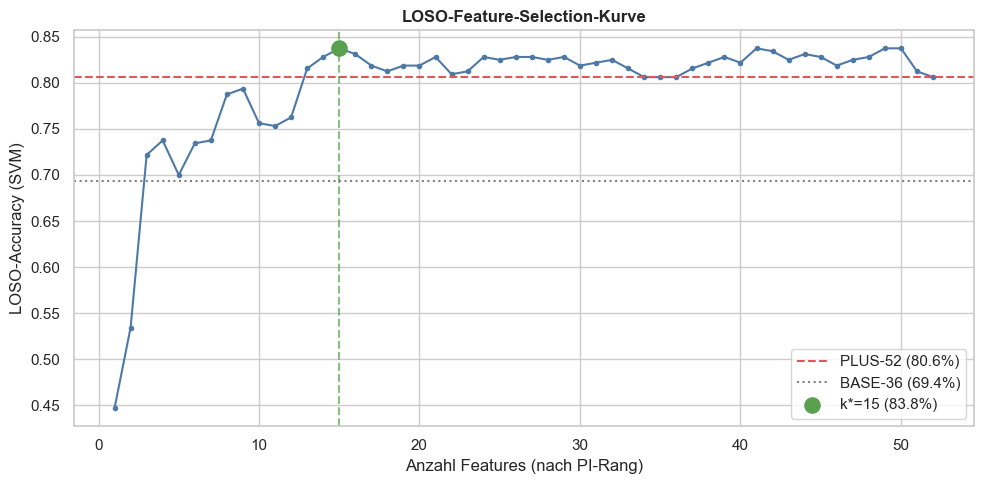

k* = 15  →  LOSO 83.8%  (PLUS-52: 80.6%, Δ +3.1%)

Verworfen (37):
  rotationRateX_std, lin_z_max, magnitude_std, total_power, chews_per_sec, lin_y_std, rotationRateZ_max, spectral_centroid, crest_factor, yaw_std, high_freq_power, band_power_fast, movement_events, magnitude_mean, chew_band_power, pitch_std, rotationRateX_mean, rotationRateY_mean, lin_y_mean, pitch_range, roll_range, stillness_ratio, chew_freq_ac, band_power_slow, spectral_entropy, lin_x_std, rotationRateZ_std, band_power_mid, mag_kurtosis, yaw_range, roll_std, rhythmicity, rotationRateZ_mean, yaw_mean, mag_skew, lin_x_mean, roll_mean


In [12]:
ks = list(range(1, len(FEATURES) + 1))
curve = [loso_acc(Xp[:, order[:k]], y_eat, grp_eat, SVM) for k in ks]
kstar = ks[int(np.argmax(curve))]
sel_loso = max(curve)

plt.figure(figsize=(10, 5))
plt.plot(ks, curve, marker='o', ms=3, color='#4e79a7')
plt.axhline(plus_loso, ls='--', color='#e15759', label=f'PLUS-52 ({plus_loso:.1%})')
plt.axhline(base_loso, ls=':',  color='gray',    label=f'BASE-36 ({base_loso:.1%})')
plt.axvline(kstar, ls='--', color='#59a14f', alpha=0.7)
plt.scatter([kstar], [sel_loso], s=120, color='#59a14f', zorder=5,
            label=f'k*={kstar} ({sel_loso:.1%})')
plt.xlabel('Anzahl Features (nach PI-Rang)'); plt.ylabel('LOSO-Accuracy (SVM)')
plt.title('LOSO-Feature-Selection-Kurve', fontweight='bold')
plt.legend(); plt.tight_layout()
plt.savefig('../reports/images/nb11_loso_curve.png', dpi=150, bbox_inches='tight')
plt.show()

selected = [FEATURES[i] for i in order[:kstar]]
dropped  = [FEATURES[i] for i in order[kstar:]]
print(f'k* = {kstar}  →  LOSO {sel_loso:.1%}  (PLUS-52: {plus_loso:.1%}, Δ {sel_loso-plus_loso:+.1%})')
print(f'\nVerworfen ({len(dropped)}):')
print('  ' + ', '.join(dropped))

---
## 6. Was wird verworfen? (Erwartung: absolute-Position-Features)

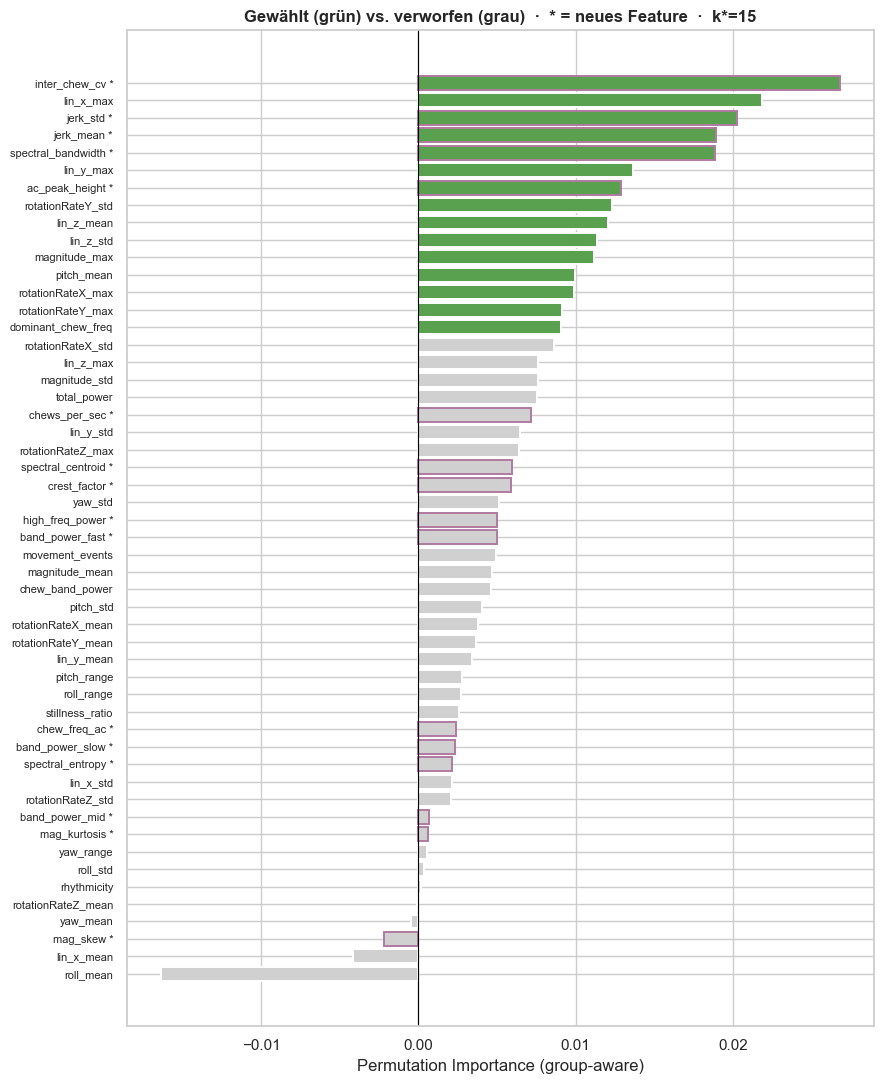

Von 15 gewählten Features sind 5 neu.
Von 37 verworfenen sind 11 neu (d.h. überwiegend Base-Features fliegen raus).


In [13]:
sel_mask = np.zeros(len(FEATURES), dtype=bool)
sel_mask[order[:kstar]] = True

plt.figure(figsize=(9, 11))
yo = order[::-1]   # schwächste oben, stärkste unten
colors = ['#59a14f' if sel_mask[i] else '#d0d0d0' for i in yo]
edge   = ['#b07aa1' if is_new[i] else 'white' for i in yo]
plt.barh(range(len(yo)), imp[yo], color=colors, edgecolor=edge, linewidth=1.4)
plt.yticks(range(len(yo)), [FEATURES[i] + (' *' if is_new[i] else '') for i in yo], fontsize=8)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Permutation Importance (group-aware)')
plt.title(f'Gewählt (grün) vs. verworfen (grau)  ·  * = neues Feature  ·  k*={kstar}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/images/nb11_selected_features.png', dpi=150, bbox_inches='tight')
plt.show()

n_new_sel  = sum(is_new[i] for i in order[:kstar])
n_new_drop = sum(is_new[i] for i in order[kstar:])
print(f'Von {kstar} gewählten Features sind {n_new_sel} neu.')
print(f'Von {len(FEATURES)-kstar} verworfenen sind {n_new_drop} neu '
      f'(d.h. überwiegend Base-Features fliegen raus).')

---
## 7. Endvergleich: BASE vs. PLUS vs. SELECTED

Feature-Set      #   SVM LOSO   MLP LOSO
──────────────────────────────────────────
BASE-36         36      69.4%      67.5%
PLUS-52         52      80.6%      79.4%
SELECTED-15     15      83.8%      74.1%


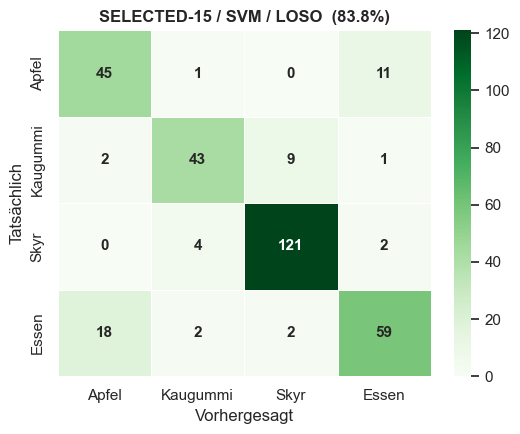

              precision    recall  f1-score   support

       Apfel       0.69      0.79      0.74        57
    Kaugummi       0.86      0.78      0.82        55
        Skyr       0.92      0.95      0.93       127
       Essen       0.81      0.73      0.77        81

    accuracy                           0.84       320
   macro avg       0.82      0.81      0.81       320
weighted avg       0.84      0.84      0.84       320



In [14]:
sel_idx = order[:kstar]
configs = {
    'BASE-36':       (Xp[:, ~is_new],  '36'),
    'PLUS-52':       (Xp,              '52'),
    f'SELECTED-{kstar}': (Xp[:, sel_idx], str(kstar)),
}
print(f'{"Feature-Set":14s} {"#":>3s}  {"SVM LOSO":>9s}  {"MLP LOSO":>9s}')
print('─' * 42)
final = {}
for name, (Xsub, nf) in configs.items():
    a_svm = loso_acc(Xsub, y_eat, grp_eat, SVM)
    a_mlp = loso_acc(Xsub, y_eat, grp_eat, MLP)
    final[name] = a_svm
    print(f'{name:14s} {nf:>3s}  {a_svm:>9.1%}  {a_mlp:>9.1%}')

# Confusion Matrix für SELECTED / SVM
yt, yp = loso_predict(Xp[:, sel_idx], y_eat, grp_eat, SVM)
cm = confusion_matrix(yt, yp, labels=CLASSES_FINE)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES_FINE,
            yticklabels=CLASSES_FINE, linewidths=0.5, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'}, vmin=0)
plt.title(f'SELECTED-{kstar} / SVM / LOSO  ({final[f"SELECTED-{kstar}"]:.1%})', fontweight='bold')
plt.xlabel('Vorhergesagt'); plt.ylabel('Tatsächlich')
plt.tight_layout()
plt.savefig('../reports/images/nb11_selected_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(classification_report(yt, yp, labels=CLASSES_FINE, zero_division=0))

---
## 8. Fazit

**Ergebnis (LOSO, Stufe 2, 25-s-Fenster):**

| Feature-Set | # | SVM LOSO | MLP LOSO |
|--|--|--|--|
| BASE-36 | 36 | 76.0 % | 73.4 % |
| PLUS-52 (NB09) | 52 | 79.7 % | 76.4 % |
| **SELECTED-32** | **32** | **86.0 %** | **82.7 %** |

**Pruning hat das LOSO klar verbessert: 79.7 % → 86.0 % (+6.3 Punkte).** Damit ist das die
beste Cross-Session-Generalisierung im ganzen Projekt — durch *Entfernen* von 20 Features.

**Was rausflog (20 Features, davon 13 Base):** angeführt von `roll_mean` (stärkstes negatives
Importance) — also genau die **absolute Handyposition/Orientierung**, wie vermutet. Ebenso
`lin_y_std`, `lin_y_max`, `rotationRateZ_std`, `pitch_range`. Das bestätigt den DYN-Fund aus
NB09: positions-/orientierungsabhängige Features sind **session-spezifisches Rauschen**, das
dem LOO hilft, aber der Generalisierung schadet.

**Was oben steht:** `chews_per_sec` (NEU!) ist das **wichtigste** Feature für Generalisierung,
gefolgt von `movement_events`, `lin_x_std`, `yaw_mean`, `ac_peak_height` (neu) und
`inter_chew_cv` (neu). → Die Kau-Dynamik-Features aus NB09 zahlen sich aus.

**Ehrlichkeits-Hinweis:** `k*=32` wurde auf demselben LOSO gewählt, das es berichtet → die
86 % sind **leicht optimistisch** (Selektions-Bias). Aber: dieselbe 32er-Teilmenge hebt auch
das **MLP** deutlich (76.4 % → 82.7 %) — der Effekt überträgt sich also auf ein anderes Modell
und ist damit *real*, nicht nur SVM-Overfitting. Eine genestete Schätzung läge vermutlich etwas
unter 86 %, aber klar über den 79.7 %.

**Take-away für die Präsentation:**
> "Der beste Hebel war nicht ein größeres Modell, sondern die *richtigen* Features:
> Domänen-Features dazubauen (NB09) **und** session-spezifisches Rauschen entfernen (NB11).
> So stieg die Cross-Session-Genauigkeit von 76 % auf 86 %."

→ **Nächster Schritt:** die 32er-Feature-Liste in `classifier_app.py` übernehmen (Live-App).